In [1]:
import yfinance as yf

ticker = yf.Ticker("^GSPC")


df = ticker.history(start="1990-01-01", auto_adjust=True)


df.drop(columns=['Dividends','Stock Splits'],inplace=True)


df

,Open,High,Low,Close,Volume
Date,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000
...,...,...,...,...,...
2025-10-20 00:00:00-04:00,6690.049805,6744.350098,6690.049805,6735.129883,4672170000
2025-10-21 00:00:00-04:00,6736.750000,6752.160156,6722.029785,6735.350098,5245020000
2025-10-22 00:00:00-04:00,6741.339844,6741.750000,6655.689941,6699.399902,5710010000


In [2]:
import numpy as np
from sklearn.preprocessing import  MinMaxScaler

close_price  =  df['Close'].values


scaler_sp500 = MinMaxScaler(feature_range=(0,1))

scaled_df = scaler_sp500.fit_transform(close_price.reshape(-1,1))

train_size = int(len(scaled_df)*0.8)

train_data = scaled_df[:train_size]
test_data = scaled_df[train_size:] 

In [3]:
def seq(data,seq_len):

    x,y = [],[]

    for i in range(seq_len,len(data)):
        x.append(data[i-seq_len:i,0])
        y.append(data[i,0])
    return np.array(x), np.array(y)

In [4]:
seq_len = 60

x_train,y_train = seq(train_data,seq_len)

x_test,y_test =  seq(test_data,seq_len)


x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [5]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import LSTM,GRU

lstm_sp500 = models.Sequential()

lstm_sp500.add(LSTM(units=100,return_sequences=True,input_shape=(x_train.shape[1],1)))
lstm_sp500.add(layers.Dropout(0.2))

lstm_sp500.add(LSTM(units=100,return_sequences=False))
lstm_sp500.add(layers.Dropout(0.2))

lstm_sp500.add(layers.Dense(1)) 

lstm_sp500.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae'])

lstm_sp500.fit(x_train,y_train,epochs=100,batch_size=32)

c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 30s 119ms/step - loss: 5.6252e-04 - mae: 0.0126
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 41s 185ms/step - loss: 1.2297e-04 - mae: 0.0078
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 41s 184ms/step - loss: 1.1494e-04 - mae: 0.0076
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 38s 169ms/step - loss: 9.6280e-05 - mae: 0.0069
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 37s 167ms/step - loss: 8.6349e-05 - mae: 0.0066
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 43s 193ms/step - loss: 7.5419e-05 - mae: 0.0063
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 83s 196ms/step - loss: 6.9681e-05 - mae: 0.0059
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 85s 207ms/step - loss: 6.9883e-05 - mae: 0.0060
Epoch 9/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 44s 198ms/step - loss: 6.0620e-05 - mae: 0.0055
Epoch 10/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 82s 197ms/step - loss: 5.8966e-05 - mae: 0.0056
Epoch 11/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 58s 90ms/step - loss: 5.3331e-05 - mae: 0.0052
Epoch 12/100
224/224

In [6]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.layers import LSTM,GRU
gru_sp500 = models.Sequential()

gru_sp500.add(GRU(units=100, return_sequences=True, input_shape=(x_train.shape[1], 1)))
gru_sp500.add(layers.Dropout(0.2))

gru_sp500.add(GRU(units=100, return_sequences=False))
gru_sp500.add(layers.Dropout(0.2))

gru_sp500.add(layers.Dense(1))

gru_sp500.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_sp500.fit(x_train, y_train, epochs=100, batch_size=32)


Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - loss: 6.7434e-04 - mae: 0.0142
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - loss: 1.2350e-04 - mae: 0.0080
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 17s 74ms/step - loss: 9.7260e-05 - mae: 0.0071
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - loss: 9.5433e-05 - mae: 0.0070
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 115ms/step - loss: 8.3661e-05 - mae: 0.0066
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 7.6552e-05 - mae: 0.0063
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - loss: 7.3888e-05 - mae: 0.0062
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 6.3404e-05 - mae: 0.0057
Epoch 9/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 23s 104ms/step - loss: 6.5359e-05 - mae: 0.0059
Epoch 10/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 5.8268e-05 - mae: 0.0056
Epoch 11/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 24s 108ms/step - loss: 6.0725e-05 - mae: 0.0056
Epoch 12/100
224/224

55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\320704632.py:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


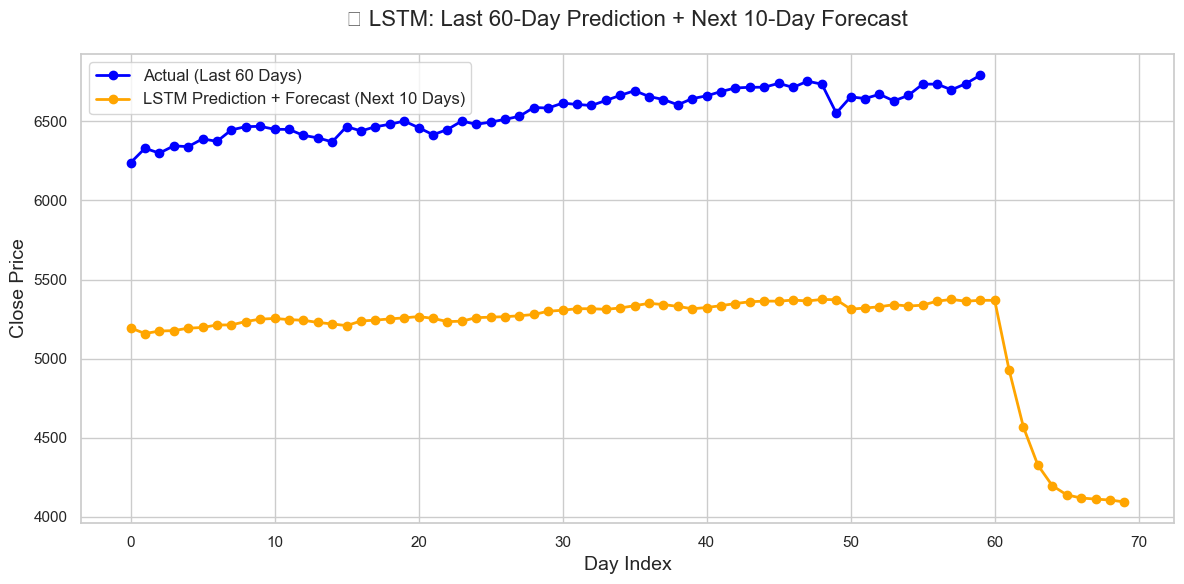

In [7]:
# 🔍 Predict using LSTM on full test set
lstm_pred = lstm_sp500.predict(x_test)
y_test_actual = scaler_sp500.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler_sp500.inverse_transform(lstm_pred)

# 🔮 Forecast next 10 days using LSTM
future_preds = []
current_seq = x_test[-1]

for _ in range(10):
    next_scaled = lstm_sp500.predict(current_seq.reshape(1, seq_len, 1))[0][0]
    future_preds.append(next_scaled)
    current_seq = np.append(current_seq[1:], [[next_scaled]], axis=0)

future_prices = scaler_sp500.inverse_transform(np.array(future_preds).reshape(-1, 1))

# 🧪 Combine last 60 predicted + next 10 forecasted
last_60_pred = lstm_pred_actual[-60:]  # Last 60 predicted values
extended_pred = np.concatenate((last_60_pred, future_prices), axis=0)

# 📊 Plot actual vs extended prediction
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 🎨 Styling
sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), extended_pred, label='LSTM Prediction + Forecast (Next 10 Days)', color='orange', marker='o')
plt.title("📈 LSTM: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\1463607758.py:42: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


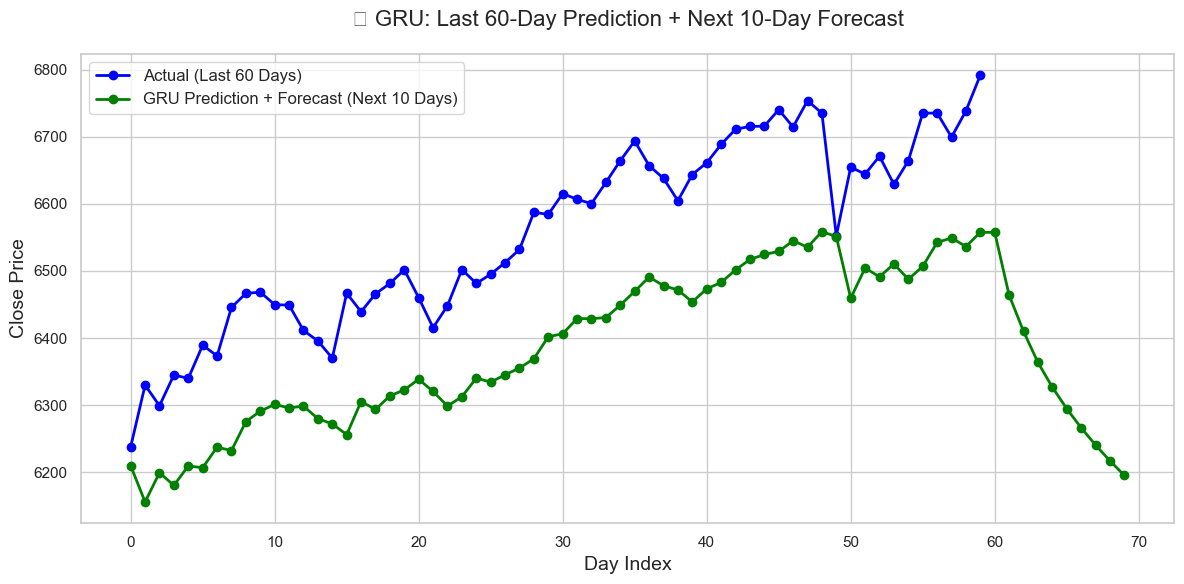

In [8]:
# 🎨 Styling
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

# 🔍 Predict on test set
gru_pred = gru_sp500.predict(x_test)
gru_pred_actual = scaler_sp500.inverse_transform(gru_pred)
y_test_actual = scaler_sp500.inverse_transform(y_test.reshape(-1, 1))

# 🔮 Forecast next 10 days
gru_future_preds = []
gru_current_seq = x_test[-1]

for _ in range(10):
    next_scaled = gru_sp500.predict(gru_current_seq.reshape(1, x_test.shape[1], 1))[0][0]
    gru_future_preds.append(next_scaled)
    gru_current_seq = np.append(gru_current_seq[1:], [[next_scaled]], axis=0)

gru_forecast = scaler_sp500.inverse_transform(np.array(gru_future_preds).reshape(-1, 1))

# 🧠 Combine predictions
gru_last_60_pred = gru_pred_actual[-60:]
gru_extended_pred = np.concatenate([gru_last_60_pred, gru_forecast])

# 📊 Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU Prediction + Forecast (Next 10 Days)', color='green', marker='o')
plt.title("📈 GRU: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\73366708.py:9: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


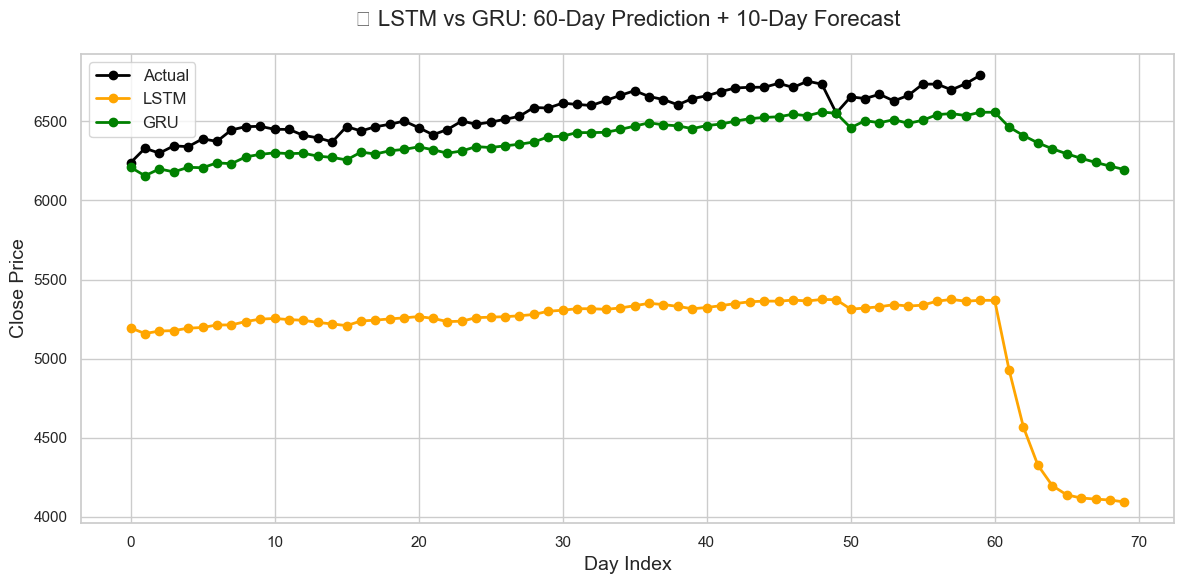

In [9]:
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual', color='black', marker='o')
plt.plot(range(70), extended_pred, label='LSTM', color='orange', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU', color='green', marker='o')
plt.title("📊 LSTM vs GRU: 60-Day Prediction + 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()


In [30]:
import joblib
joblib.dump(df, 'df_sp500.pkl')
joblib.dump(scaler_sp500, 'scaler_sp500.pkl')
gru_sp500.save("gru_model_sp500.keras")



In [11]:
from sklearn.metrics import mean_absolute_error

print("LSTM MAE:", mean_absolute_error(y_test_actual, lstm_pred_actual))
print("GRU  MAE:", mean_absolute_error(y_test_actual, gru_pred_actual))

LSTM MAE: 326.70142049270237
GRU  MAE: 55.606230272877866


c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 35s 119ms/step - loss: 5.3191e-05 - mae: 0.0036
Epoch 2/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 29s 130ms/step - loss: 1.4815e-05 - mae: 0.0025
Epoch 3/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 18s 78ms/step - loss: 1.6556e-05 - mae: 0.0027
Epoch 4/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 28s 127ms/step - loss: 1.4108e-05 - mae: 0.0025
Epoch 5/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 29s 128ms/step - loss: 1.2812e-05 - mae: 0.0024
Epoch 6/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step - loss: 1.6278e-05 - mae: 0.0028
Epoch 7/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 25s 110ms/step - loss: 1.2878e-05 - mae: 0.0024
Epoch 8/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 30s 133ms/step - loss: 1.3662e-05 - mae: 0.0025
Epoch 9/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 26s 117ms/step - loss: 1.2049e-05 - mae: 0.0023
Epoch 10/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - loss: 1.3931e-05 - mae: 0.0026
Epoch 11/100
224/224 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - loss: 1.0765e-05 - mae: 0.0022
Epoch 12/100
224/224 ━

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\968987926.py:107: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


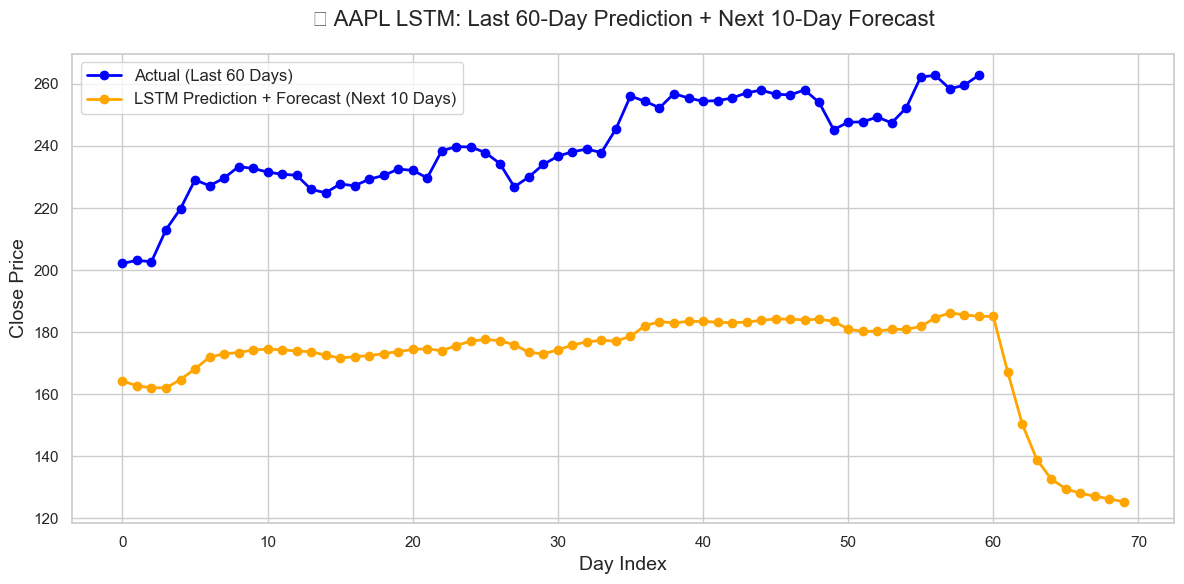

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\968987926.py:119: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()


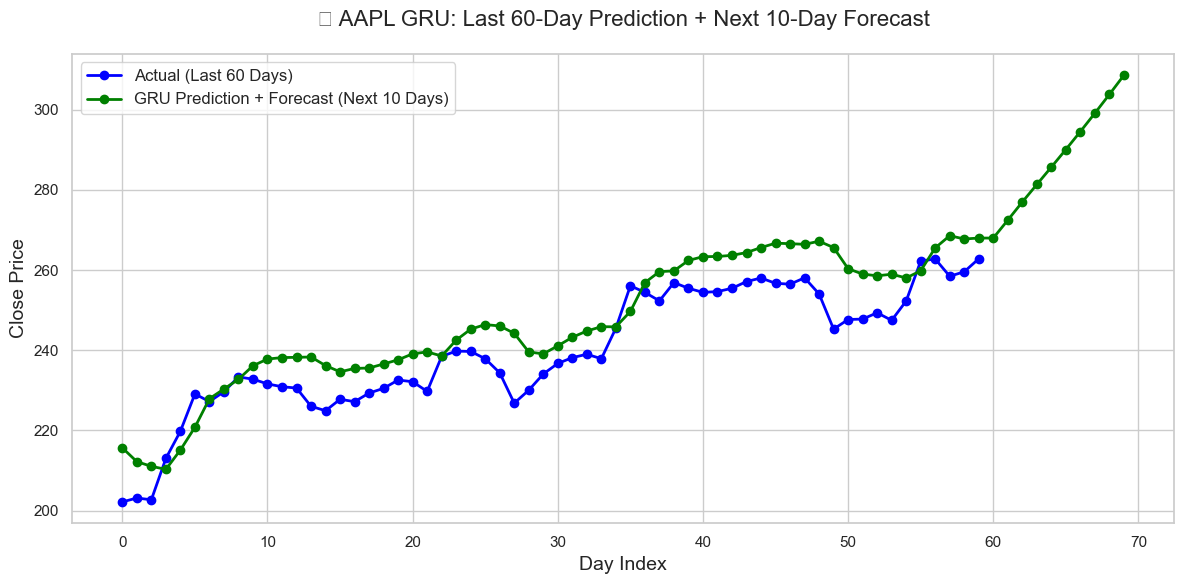

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\968987926.py:132: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


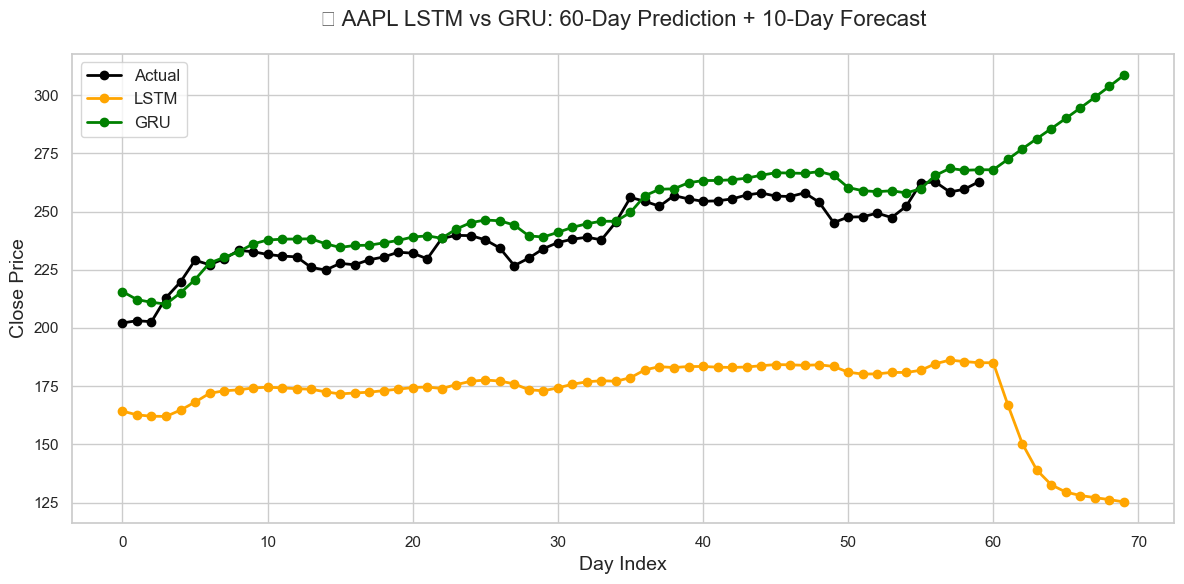

In [12]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler


ticker1 = yf.Ticker("AAPL")
df1 = ticker1.history(start="1990-01-01", auto_adjust=True)
close_price = df1['Close'].values
scaler_aapl = MinMaxScaler(feature_range=(0, 1))
scaled_df = scaler_aapl.fit_transform(close_price.reshape(-1, 1))

train_size = int(len(scaled_df) * 0.8)
train_data = scaled_df[:train_size]
test_data = scaled_df[train_size:]

def seq(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

seq_len = 60
x_train, y_train = seq(train_data, seq_len)
x_test, y_test = seq(test_data, seq_len)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LSTM, GRU

# LSTM Model
lstm_aapl = models.Sequential([
    LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    LSTM(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
lstm_aapl.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_aapl.fit(x_train, y_train, epochs=100, batch_size=32)

# GRU Model
gru_aapl = models.Sequential([
    GRU(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    GRU(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
gru_aapl.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_aapl.fit(x_train, y_train, epochs=100, batch_size=32)

# LSTM Prediction + Forecast
lstm_pred = lstm_aapl.predict(x_test)
y_test_actual = scaler_aapl.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler_aapl.inverse_transform(lstm_pred)

future_preds = []
current_seq = x_test[-1]
for _ in range(10):
    next_scaled = lstm_aapl.predict(current_seq.reshape(1, seq_len, 1))[0][0]
    future_preds.append(next_scaled)
    current_seq = np.append(current_seq[1:], [[next_scaled]], axis=0)

future_prices = scaler_aapl.inverse_transform(np.array(future_preds).reshape(-1, 1))
last_60_pred = lstm_pred_actual[-60:]
extended_pred = np.concatenate((last_60_pred, future_prices), axis=0)

# GRU Prediction + Forecast
gru_pred = gru_aapl.predict(x_test)
gru_pred_actual = scaler_aapl.inverse_transform(gru_pred)

gru_future_preds = []
gru_current_seq = x_test[-1]
for _ in range(10):
    next_scaled = gru_aapl.predict(gru_current_seq.reshape(1, seq_len, 1))[0][0]
    gru_future_preds.append(next_scaled)
    gru_current_seq = np.append(gru_current_seq[1:], [[next_scaled]], axis=0)

gru_forecast = scaler_aapl.inverse_transform(np.array(gru_future_preds).reshape(-1, 1))
gru_last_60_pred = gru_pred_actual[-60:]
gru_extended_pred = np.concatenate((gru_last_60_pred, gru_forecast), axis=0)

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

# LSTM Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), extended_pred, label='LSTM Prediction + Forecast (Next 10 Days)', color='orange', marker='o')
plt.title("📈 AAPL LSTM: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# GRU Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU Prediction + Forecast (Next 10 Days)', color='green', marker='o')
plt.title("📈 AAPL GRU: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# Combined Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual', color='black', marker='o')
plt.plot(range(70), extended_pred, label='LSTM', color='orange', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU', color='green', marker='o')
plt.title("📊 AAPL LSTM vs GRU: 60-Day Prediction + 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [31]:

joblib.dump(df1, 'df_aapl.pkl')
joblib.dump(scaler_aapl, 'scaler_aapl.pkl')
gru_aapl.save("gru_model_aapl.keras")



In [14]:
from sklearn.metrics import mean_absolute_error

print("LSTM MAE:", mean_absolute_error(y_test_actual, lstm_pred_actual))
print("GRU  MAE:", mean_absolute_error(y_test_actual, gru_pred_actual))

LSTM MAE: 20.65299934234182
GRU  MAE: 3.9054949697587413


c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 34s 215ms/step - loss: 0.0017 - mae: 0.0197
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - loss: 6.8163e-04 - mae: 0.0127
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 17s 152ms/step - loss: 6.5446e-04 - mae: 0.0123
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 7.1898e-04 - mae: 0.0148
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 5.3260e-04 - mae: 0.0107
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 5.4150e-04 - mae: 0.0116
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - loss: 5.0687e-04 - mae: 0.0116
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - loss: 5.1847e-04 - mae: 0.0113
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 209ms/step - loss: 4.2514e-04 - mae: 0.0100
Epoch 10/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 21s 219ms/step - loss: 5.5848e-04 - mae: 0.0131
Epoch 11/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - loss: 4.7109e-04 - mae: 0.0115
Epoch 12/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/s

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\3720168869.py:108: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


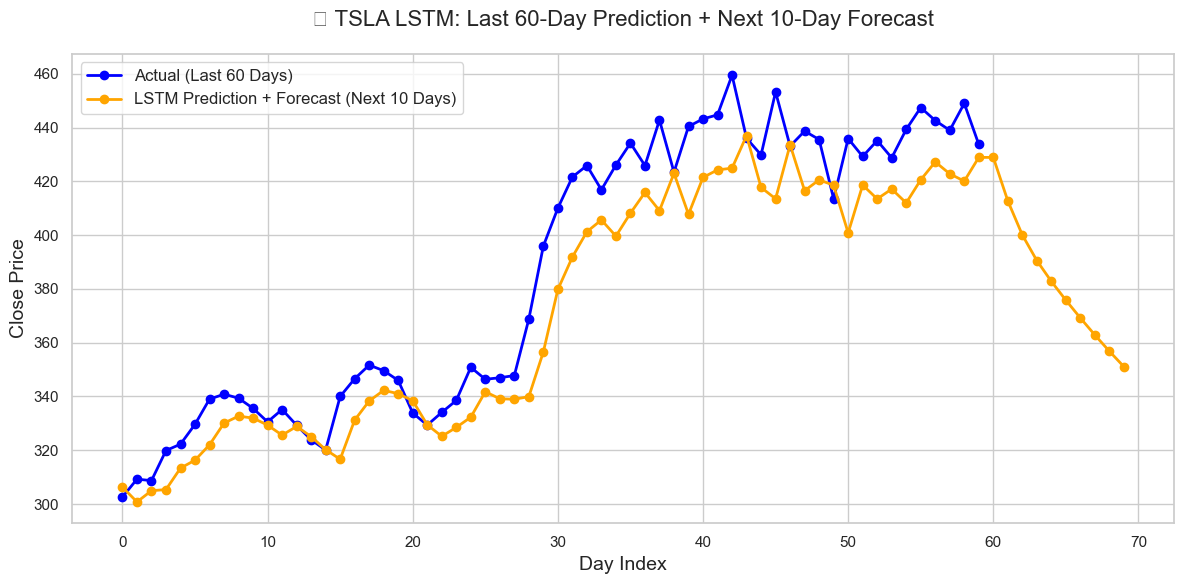

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\3720168869.py:120: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()


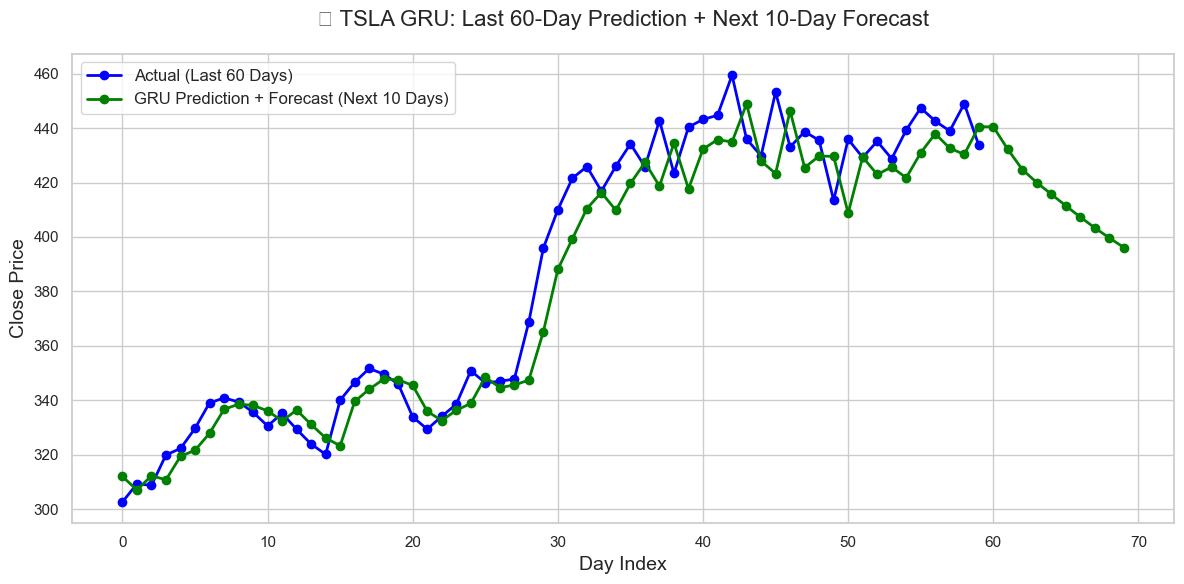

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\3720168869.py:133: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


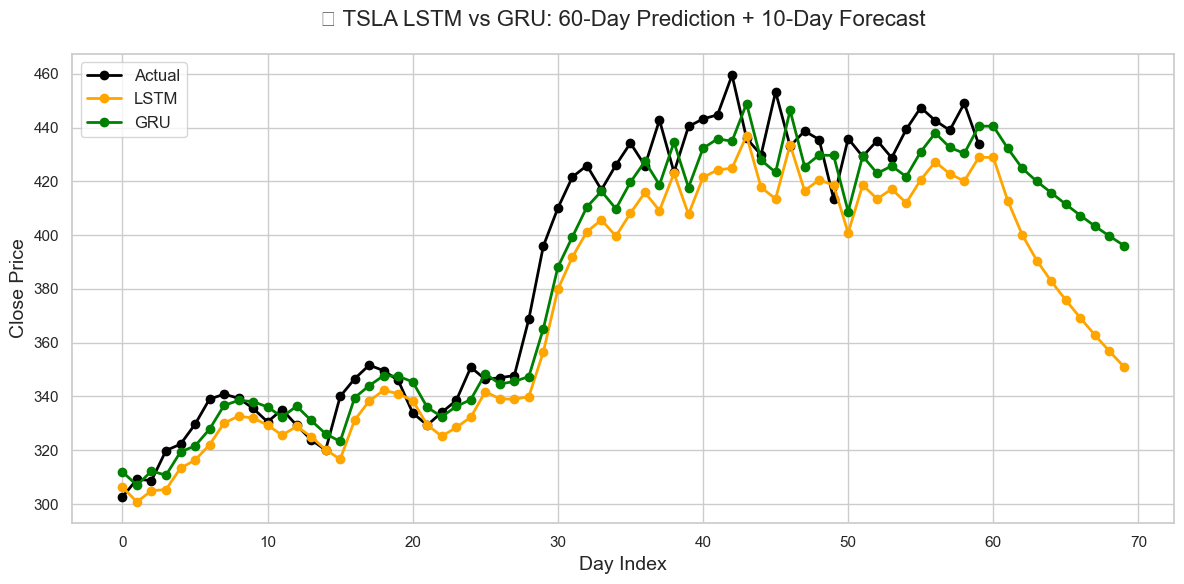

In [15]:
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LSTM, GRU
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 🔹 Load TSLA data
ticker2 = yf.Ticker("TSLA")
df2 = ticker2.history(start="1990-01-01", auto_adjust=True)
close_price = df2['Close'].values

# 🔹 Scaling
scaler_tsla = MinMaxScaler(feature_range=(0, 1))
scaled_df = scaler_tsla.fit_transform(close_price.reshape(-1, 1))
train_size = int(len(scaled_df) * 0.8)
train_data = scaled_df[:train_size]
test_data = scaled_df[train_size:]

# 🔹 Sequence creation
def seq(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

seq_len = 60
x_train, y_train = seq(train_data, seq_len)
x_test, y_test = seq(test_data, seq_len)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# 🔹 LSTM Model
lstm_tsla = models.Sequential([
    LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    LSTM(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
lstm_tsla.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_tsla.fit(x_train, y_train, epochs=100, batch_size=32)

# 🔹 GRU Model
gru_tsla = models.Sequential([
    GRU(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    GRU(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
gru_tsla.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_tsla.fit(x_train, y_train, epochs=100, batch_size=32)

# 🔹 LSTM Prediction + Forecast
lstm_pred = lstm_tsla.predict(x_test)
y_test_actual = scaler_tsla.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler_tsla.inverse_transform(lstm_pred)

future_preds = []
current_seq = x_test[-1]
for _ in range(10):
    next_scaled = lstm_tsla.predict(current_seq.reshape(1, seq_len, 1))[0][0]
    future_preds.append(next_scaled)
    current_seq = np.append(current_seq[1:], [[next_scaled]], axis=0)

future_prices = scaler_tsla.inverse_transform(np.array(future_preds).reshape(-1, 1))
last_60_pred = lstm_pred_actual[-60:]
extended_pred = np.concatenate((last_60_pred, future_prices), axis=0)

# 🔹 GRU Prediction + Forecast
gru_pred = gru_tsla.predict(x_test)
gru_pred_actual = scaler_tsla.inverse_transform(gru_pred)

gru_future_preds = []
gru_current_seq = x_test[-1]
for _ in range(10):
    next_scaled = gru_tsla.predict(gru_current_seq.reshape(1, seq_len, 1))[0][0]
    gru_future_preds.append(next_scaled)
    gru_current_seq = np.append(gru_current_seq[1:], [[next_scaled]], axis=0)

gru_forecast = scaler_tsla.inverse_transform(np.array(gru_future_preds).reshape(-1, 1))
gru_last_60_pred = gru_pred_actual[-60:]
gru_extended_pred = np.concatenate((gru_last_60_pred, gru_forecast), axis=0)

# 🔹 Plotting
sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

# LSTM Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), extended_pred, label='LSTM Prediction + Forecast (Next 10 Days)', color='orange', marker='o')
plt.title("📈 TSLA LSTM: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# GRU Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU Prediction + Forecast (Next 10 Days)', color='green', marker='o')
plt.title("📈 TSLA GRU: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# Combined Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual', color='black', marker='o')
plt.plot(range(70), extended_pred, label='LSTM', color='orange', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU', color='green', marker='o')
plt.title("📊 TSLA LSTM vs GRU: 60-Day Prediction + 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [32]:

joblib.dump(df2, 'df_tsla.pkl')
joblib.dump(scaler_tsla, 'scaler_tsla.pkl')
gru_tsla.save("gru_model_tsla.keras")




In [17]:
from sklearn.metrics import mean_absolute_error

print("LSTM MAE:", mean_absolute_error(y_test_actual, lstm_pred_actual))
print("GRU  MAE:", mean_absolute_error(y_test_actual, gru_pred_actual))

LSTM MAE: 8.213966444636998
GRU  MAE: 8.062909619192059


c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 46s 188ms/step - loss: 4.1994e-04 - mae: 0.0100
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - loss: 1.0519e-04 - mae: 0.0067
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 36s 191ms/step - loss: 9.5974e-05 - mae: 0.0063
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 32s 170ms/step - loss: 9.0361e-05 - mae: 0.0062
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 43s 182ms/step - loss: 8.7271e-05 - mae: 0.0061
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 39s 208ms/step - loss: 7.2712e-05 - mae: 0.0057
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 39s 211ms/step - loss: 7.1600e-05 - mae: 0.0056
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 39s 210ms/step - loss: 6.8355e-05 - mae: 0.0056
Epoch 9/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 36s 194ms/step - loss: 7.0912e-05 - mae: 0.0056
Epoch 10/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - loss: 6.2839e-05 - mae: 0.0053
Epoch 11/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 35s 187ms/step - loss: 6.5881e-05 - mae: 0.0053
Epoch 12/100
186/18

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\790483936.py:108: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


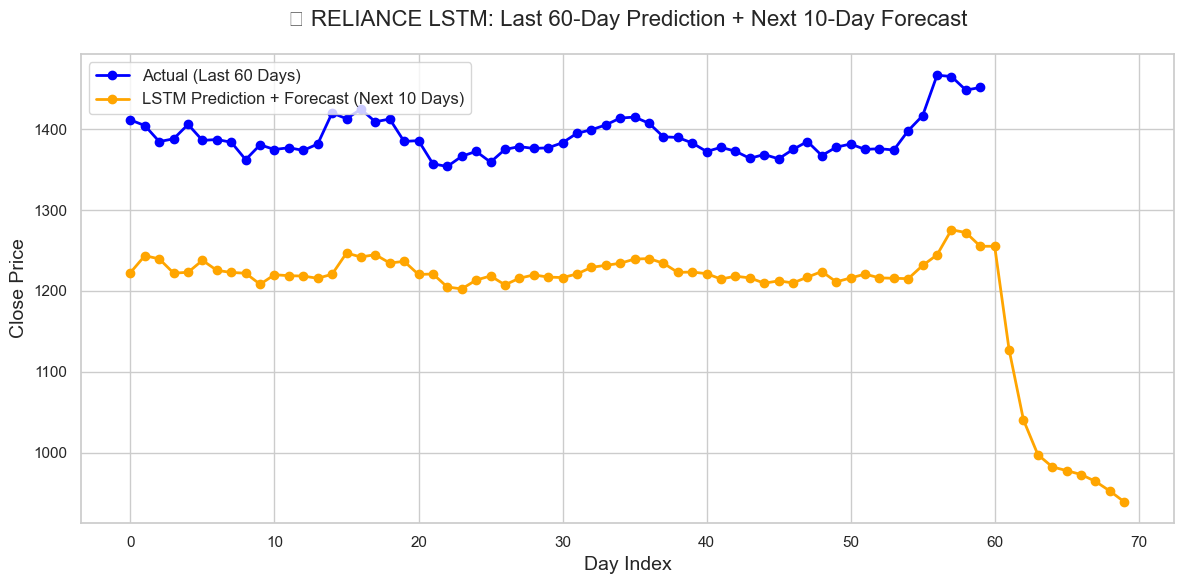

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\790483936.py:120: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()


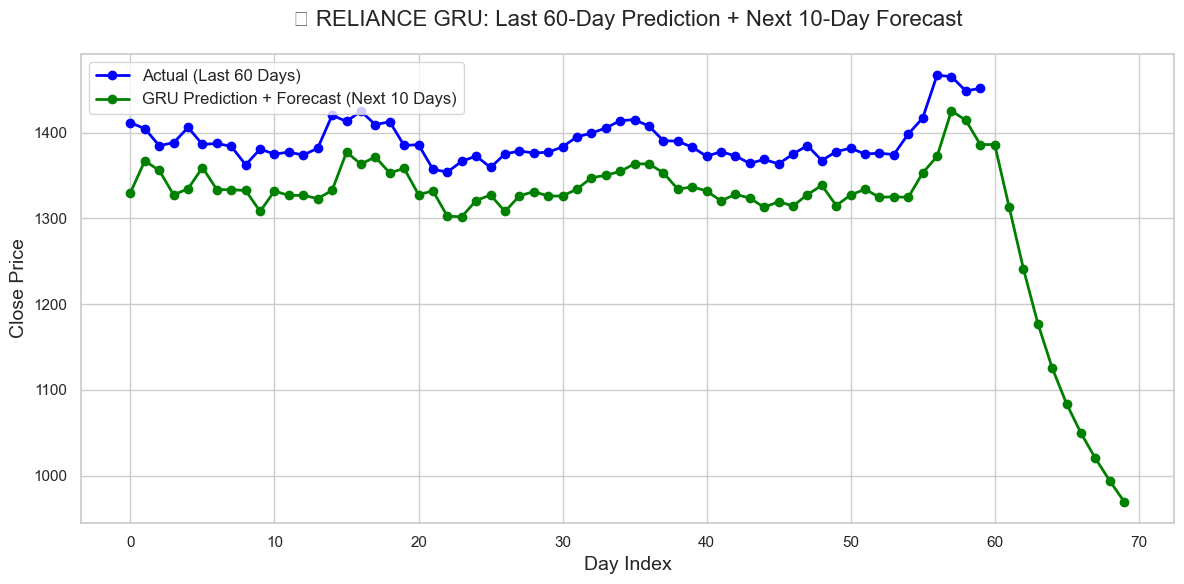

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\790483936.py:133: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


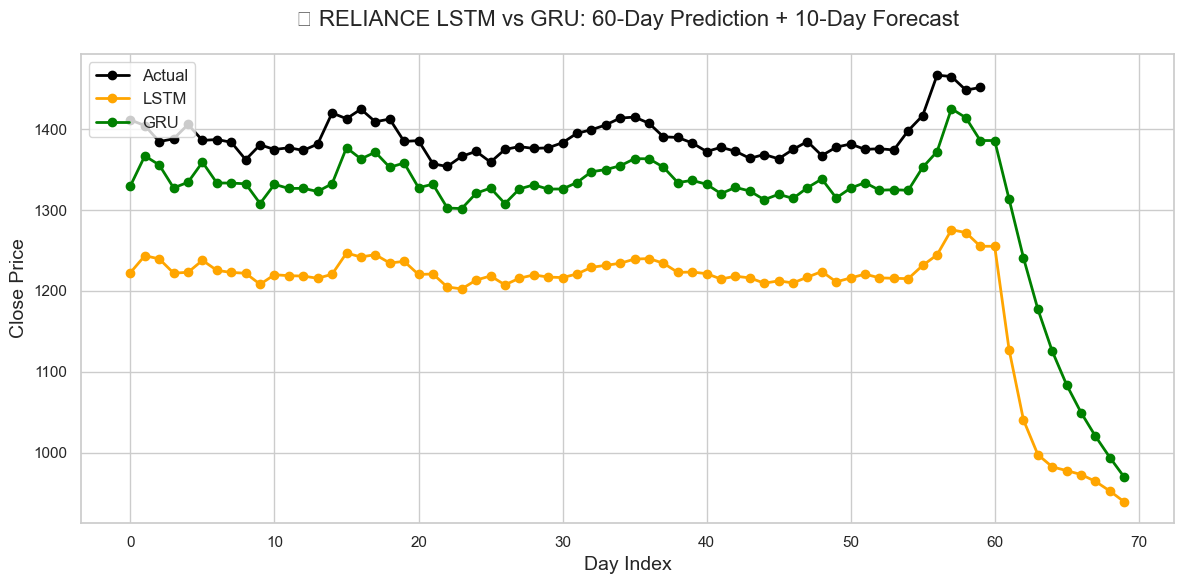

In [ ]:
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LSTM, GRU
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 🔹 Load RELIANCE data
ticker3 = yf.Ticker("RELIANCE.NS")
df3 = ticker3.history(start="1990-01-01", auto_adjust=True)
close_price = df3['Close'].values

# 🔹 Scaling
scaler_reliance = MinMaxScaler(feature_range=(0, 1))
scaled_df = scaler_reliance.fit_transform(close_price.reshape(-1, 1))
train_size = int(len(scaled_df) * 0.8)
train_data = scaled_df[:train_size]
test_data = scaled_df[train_size:]

# 🔹 Sequence creation
def seq(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

seq_len = 60
x_train, y_train = seq(train_data, seq_len)
x_test, y_test = seq(test_data, seq_len)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# 🔹 LSTM Model
lstm_reliance = models.Sequential([
    LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    LSTM(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
lstm_reliance.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_reliance.fit(x_train, y_train, epochs=100, batch_size=32)

# 🔹 GRU Model
gru_reliance = models.Sequential([
    GRU(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    GRU(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
gru_reliance.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_reliance.fit(x_train, y_train, epochs=100, batch_size=32)

# 🔹 LSTM Prediction + Forecast
lstm_pred = lstm_reliance.predict(x_test)
y_test_actual = scaler_reliance.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler_reliance.inverse_transform(lstm_pred)

future_preds = []
current_seq = x_test[-1]
for _ in range(10):
    next_scaled = lstm_reliance.predict(current_seq.reshape(1, seq_len, 1))[0][0]
    future_preds.append(next_scaled)
    current_seq = np.append(current_seq[1:], [[next_scaled]], axis=0)

future_prices = scaler_reliance.inverse_transform(np.array(future_preds).reshape(-1, 1))
last_60_pred = lstm_pred_actual[-60:]
extended_pred = np.concatenate((last_60_pred, future_prices), axis=0)

# 🔹 GRU Prediction + Forecast
gru_pred = gru_reliance.predict(x_test)
gru_pred_actual = scaler_reliance.inverse_transform(gru_pred)

gru_future_preds = []
gru_current_seq = x_test[-1]
for _ in range(10):
    next_scaled = gru_reliance.predict(gru_current_seq.reshape(1, seq_len, 1))[0][0]
    gru_future_preds.append(next_scaled)
    gru_current_seq = np.append(gru_current_seq[1:], [[next_scaled]], axis=0)

gru_forecast = scaler_reliance.inverse_transform(np.array(gru_future_preds).reshape(-1, 1))
gru_last_60_pred = gru_pred_actual[-60:]
gru_extended_pred = np.concatenate((gru_last_60_pred, gru_forecast), axis=0)

# 🔹 Plotting
sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

# LSTM Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), extended_pred, label='LSTM Prediction + Forecast (Next 10 Days)', color='orange', marker='o')
plt.title("📈 RELIANCE LSTM: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# GRU Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU Prediction + Forecast (Next 10 Days)', color='green', marker='o')
plt.title("📈 RELIANCE GRU: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# Combined Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual', color='black', marker='o')
plt.plot(range(70), extended_pred, label='LSTM', color='orange', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU', color='green', marker='o')
plt.title("📊 RELIANCE LSTM vs GRU: 60-Day Prediction + 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [33]:
joblib.dump(df3, 'df_reliance.pkl')
joblib.dump(scaler_reliance, 'scaler_reliance.pkl')
gru_reliance.save("gru_model_reliance.keras")



In [20]:
from sklearn.metrics import mean_absolute_error

print("LSTM MAE:", mean_absolute_error(y_test_actual, lstm_pred_actual))
print("GRU  MAE:", mean_absolute_error(y_test_actual, gru_pred_actual))

LSTM MAE: 96.27833320336285
GRU  MAE: 38.51515634174387


c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - loss: 5.0557e-04 - mae: 0.0110
Epoch 2/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 34s 184ms/step - loss: 9.2042e-05 - mae: 0.0064
Epoch 3/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 32s 173ms/step - loss: 8.6109e-05 - mae: 0.0062
Epoch 4/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 34s 180ms/step - loss: 7.9363e-05 - mae: 0.0060
Epoch 5/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 33s 178ms/step - loss: 6.9070e-05 - mae: 0.0056
Epoch 6/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 42s 182ms/step - loss: 7.1460e-05 - mae: 0.0057
Epoch 7/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 33s 178ms/step - loss: 5.9149e-05 - mae: 0.0052
Epoch 8/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - loss: 6.3044e-05 - mae: 0.0055
Epoch 9/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - loss: 5.5422e-05 - mae: 0.0051
Epoch 10/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 5.9094e-05 - mae: 0.0052
Epoch 11/100
186/186 ━━━━━━━━━━━━━━━━━━━━ 26s 138ms/step - loss: 5.5646e-05 - mae: 0.0051
Epoch 12/100
186/18

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\2394690004.py:108: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


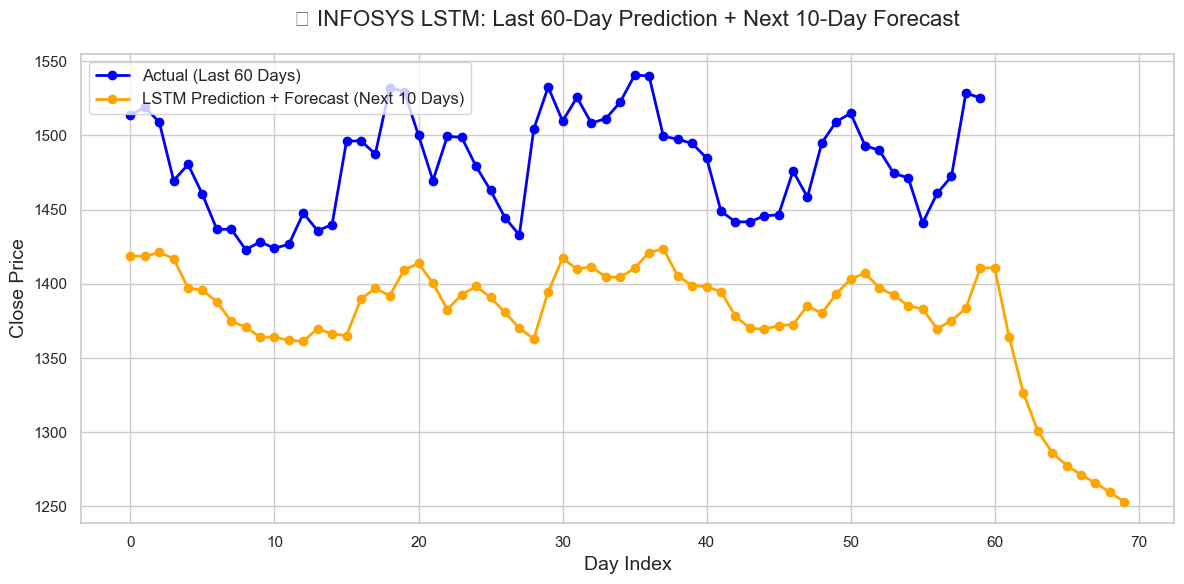

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\2394690004.py:120: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()


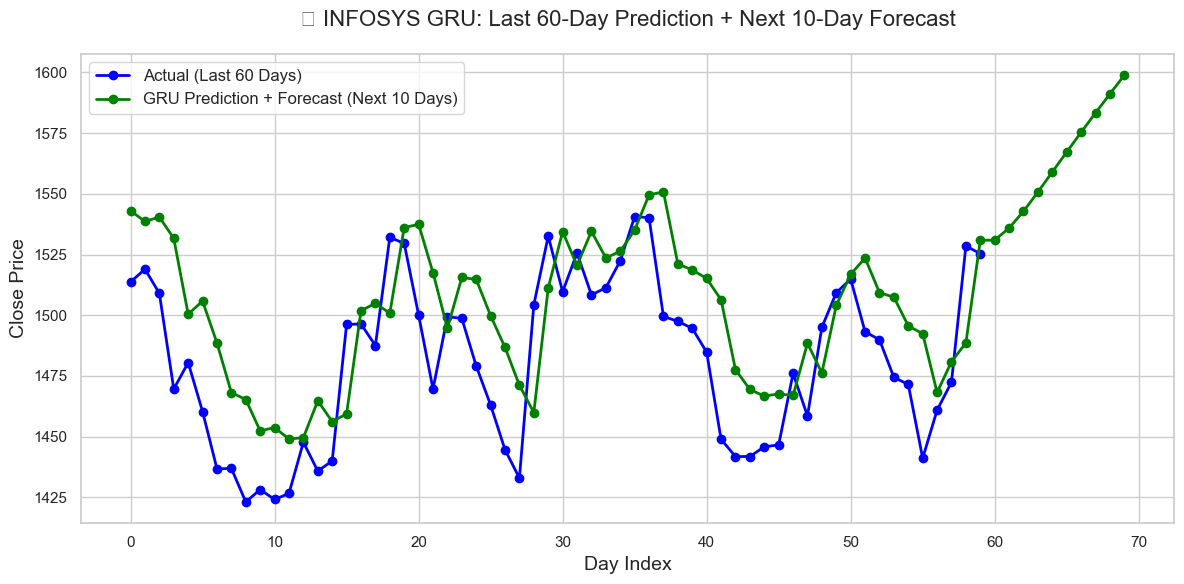

C:\Users\Risha\AppData\Local\Temp\ipykernel_4148\2394690004.py:133: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


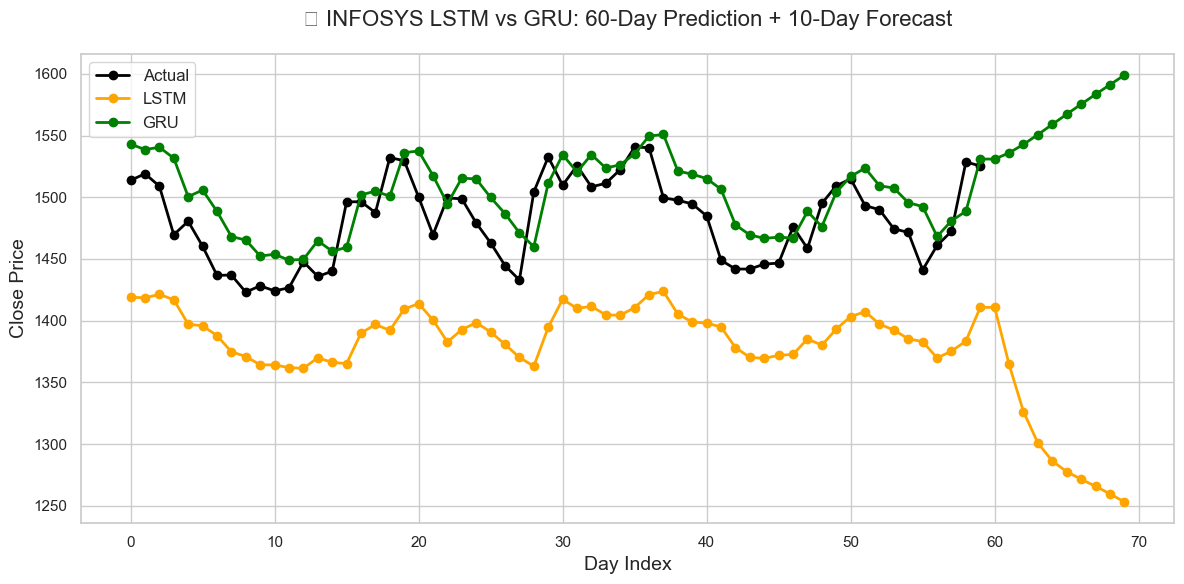

In [21]:
import yfinance as yf
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import LSTM, GRU
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# 🔹 Load INFOSYS data
ticker4 = yf.Ticker("INFY.NS")
df4 = ticker4.history(start="1990-01-01", auto_adjust=True)
close_price = df4['Close'].values

# 🔹 Scaling
scaler_infosys = MinMaxScaler(feature_range=(0, 1))
scaled_df = scaler_infosys.fit_transform(close_price.reshape(-1, 1))
train_size = int(len(scaled_df) * 0.8)
train_data = scaled_df[:train_size]
test_data = scaled_df[train_size:]

# 🔹 Sequence creation
def seq(data, seq_len):
    x, y = [], []
    for i in range(seq_len, len(data)):
        x.append(data[i-seq_len:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

seq_len = 60
x_train, y_train = seq(train_data, seq_len)
x_test, y_test = seq(test_data, seq_len)

x_train = x_train.reshape((x_train.shape[0], x_train.shape[1], 1))
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1], 1))

# 🔹 LSTM Model
lstm_infosys = models.Sequential([
    LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    LSTM(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
lstm_infosys.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
lstm_infosys.fit(x_train, y_train, epochs=100, batch_size=32)

# 🔹 GRU Model
gru_infosys = models.Sequential([
    GRU(100, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    layers.Dropout(0.2),
    GRU(100),
    layers.Dropout(0.2),
    layers.Dense(1)
])
gru_infosys.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
gru_infosys.fit(x_train, y_train, epochs=100, batch_size=32)

# 🔹 LSTM Prediction + Forecast
lstm_pred = lstm_infosys.predict(x_test)
y_test_actual = scaler_infosys.inverse_transform(y_test.reshape(-1, 1))
lstm_pred_actual = scaler_infosys.inverse_transform(lstm_pred)

future_preds = []
current_seq = x_test[-1]
for _ in range(10):
    next_scaled = lstm_infosys.predict(current_seq.reshape(1, seq_len, 1))[0][0]
    future_preds.append(next_scaled)
    current_seq = np.append(current_seq[1:], [[next_scaled]], axis=0)

future_prices = scaler_infosys.inverse_transform(np.array(future_preds).reshape(-1, 1))
last_60_pred = lstm_pred_actual[-60:]
extended_pred = np.concatenate((last_60_pred, future_prices), axis=0)

# 🔹 GRU Prediction + Forecast
gru_pred = gru_infosys.predict(x_test)
gru_pred_actual = scaler_infosys.inverse_transform(gru_pred)

gru_future_preds = []
gru_current_seq = x_test[-1]
for _ in range(10):
    next_scaled = gru_infosys.predict(gru_current_seq.reshape(1, seq_len, 1))[0][0]
    gru_future_preds.append(next_scaled)
    gru_current_seq = np.append(gru_current_seq[1:], [[next_scaled]], axis=0)

gru_forecast = scaler_infosys.inverse_transform(np.array(gru_future_preds).reshape(-1, 1))
gru_last_60_pred = gru_pred_actual[-60:]
gru_extended_pred = np.concatenate((gru_last_60_pred, gru_forecast), axis=0)

# 🔹 Plotting
sns.set(style="whitegrid")
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['legend.fontsize'] = 12
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

# LSTM Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), extended_pred, label='LSTM Prediction + Forecast (Next 10 Days)', color='orange', marker='o')
plt.title("📈 INFOSYS LSTM: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# GRU Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual (Last 60 Days)', color='blue', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU Prediction + Forecast (Next 10 Days)', color='green', marker='o')
plt.title("📈 INFOSYS GRU: Last 60-Day Prediction + Next 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

# Combined Plot
plt.figure(figsize=(12, 6))
plt.plot(range(60), y_test_actual[-60:], label='Actual', color='black', marker='o')
plt.plot(range(70), extended_pred, label='LSTM', color='orange', marker='o')
plt.plot(range(70), gru_extended_pred, label='GRU', color='green', marker='o')
plt.title("📊 INFOSYS LSTM vs GRU: 60-Day Prediction + 10-Day Forecast", pad=20)
plt.xlabel("Day Index")
plt.ylabel("Close Price")
plt.legend(loc='upper left')
plt.tight_layout()
plt.grid(True)
plt.show()

In [34]:
joblib.dump(df4, 'df_infosys.pkl')
joblib.dump(scaler_infosys, 'scaler_infosys.pkl')
gru_infosys.save("gru_model_infosys.keras")




In [23]:
from sklearn.metrics import mean_absolute_error

print("LSTM MAE:", mean_absolute_error(y_test_actual, lstm_pred_actual))
print("GRU  MAE:", mean_absolute_error(y_test_actual, gru_pred_actual))

LSTM MAE: 87.79277331441102
GRU  MAE: 20.948487070903326


In [37]:
import streamlit
import tensorflow as tf
import sklearn
import yfinance
import matplotlib
import seaborn
import joblib
import pandas as pd
import numpy as np

print("📦 Streamlit:", streamlit.__version__)
print("📦 TensorFlow:", tf.__version__)
print("📦 scikit-learn:", sklearn.__version__)
print("📦 yfinance:", yfinance.__version__)
print("📦 Matplotlib:", matplotlib.__version__)
print("📦 Seaborn:", seaborn.__version__)
print("📦 Joblib:", joblib.__version__)
print("📦 Pandas:", pd.__version__)
print("📦 NumPy:", np.__version__)

📦 Streamlit: 1.50.0
📦 TensorFlow: 2.20.0
📦 scikit-learn: 1.7.2
📦 yfinance: 0.2.66
📦 Matplotlib: 3.10.7
📦 Seaborn: 0.13.2
📦 Joblib: 1.5.2
📦 Pandas: 2.3.3
📦 NumPy: 2.2.6


In [38]:
import sys
print(sys.executable)

c:\Users\Risha\OneDrive\Documents\OneDrive\Desktop\a\.venv\Scripts\python.exe
